In [2]:
#Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import joblib

#Load dataset
df = pd.read_csv(r"C:\Users\USER\PycharmProjects\component2_traffic\traffic_simulation\final_dataset_adaptive.csv")



In [3]:
#  Remove outliers from numeric columns
numeric_cols = ["duration", "waiting_time",  "route_length", "average_speed", "time_loss", "arrival_time"]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

mask = ~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
         (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

df = df[mask].reset_index(drop=True)

print("Rows after removing outliers:", df.shape[0])

#Feature selection
features = ["duration", "route_length", "average_speed", "time_loss"]
X = df[features]
y = df["waiting_time"]
#Handle Missing Values
X = X.fillna(X.median())

Rows after removing outliers: 1710


In [4]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(len(X_test))

342


In [4]:
#Hyperparameter tuning
param_grid = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.7, 0.8, 1.0]
}

gbr = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

#Best model
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

#Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

#Clip negative predictions
y_train_pred = y_train_pred.clip(min=0)
y_test_pred = y_test_pred.clip(min=0)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}
Best CV Score: 0.9708836283598632


In [5]:
#Evaluate metrics
y_train_actual = y_train
y_test_actual = y_test

train_r2 = r2_score(y_train_actual, y_train_pred)
test_r2 = r2_score(y_test_actual, y_test_pred)
train_mae = mean_absolute_error(y_train_actual, y_train_pred)
test_mae = mean_absolute_error(y_test_actual, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_actual, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))

# Evaluation metrics table
metrics = {
    "Dataset": ["Train", "Test"],
    "R2 Score": [train_r2, test_r2],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse]
}

metrics_df = pd.DataFrame(metrics)
print("Evaluation Metrics Summary:\n")
print(metrics_df)


Evaluation Metrics Summary:

  Dataset  R2 Score        MAE       RMSE
0   Train  0.983417   7.924241  10.619946
1    Test  0.964458  10.016567  14.627489


In [6]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import make_scorer

# ---------------- CROSS-VALIDATION ----------------
# Define scoring functions
r2_scorer = "r2"
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)  # negate to match sklearn convention

# Cross-validation predictions
cv_folds = 5

# R2 scores
cv_r2_scores = cross_val_score(best_model, X, y, cv=cv_folds, scoring=r2_scorer)
cv_r2_mean = cv_r2_scores.mean()

# MAE scores (note: negate back)
cv_mae_scores = -cross_val_score(best_model, X, y, cv=cv_folds, scoring=mae_scorer)
cv_mae_mean = cv_mae_scores.mean()

# RMSE scores
y_cv_pred = cross_val_predict(best_model, X, y, cv=cv_folds)
cv_rmse = np.sqrt(mean_squared_error(y, y_cv_pred))

# ---------------- EVALUATION TABLE ----------------
metrics = {
    "Dataset": ["Train", "Test", f"{cv_folds}-Fold CV"],
    "R2 Score": [train_r2, test_r2, cv_r2_mean],
    "MAE": [train_mae, test_mae, cv_mae_mean],
    "RMSE": [train_rmse, test_rmse, cv_rmse]
}

metrics_df = pd.DataFrame(metrics)
print("Evaluation Metrics Summary (Train/Test/CV):\n")
print(metrics_df)

Evaluation Metrics Summary (Train/Test/CV):

     Dataset  R2 Score        MAE       RMSE
0      Train  0.983417   7.924241  10.619946
1       Test  0.964458  10.016567  14.627489
2  5-Fold CV  0.966995  10.259852  14.528283


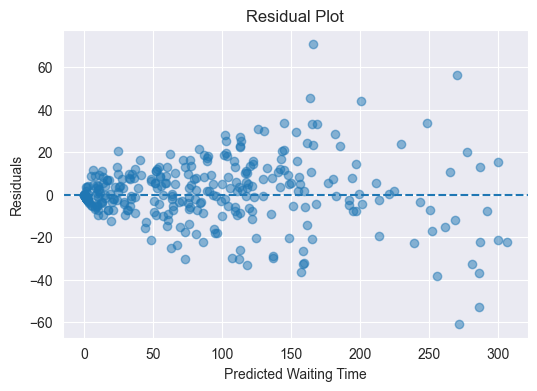

In [102]:
#Residual plot
residuals = y_test_actual - y_test_pred
plt.figure(figsize=(6,4))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Waiting Time")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Feature Importance:
         Feature  Importance
3      time_loss    0.974522
2  average_speed    0.013339
1   route_length    0.008533
0       duration    0.003606


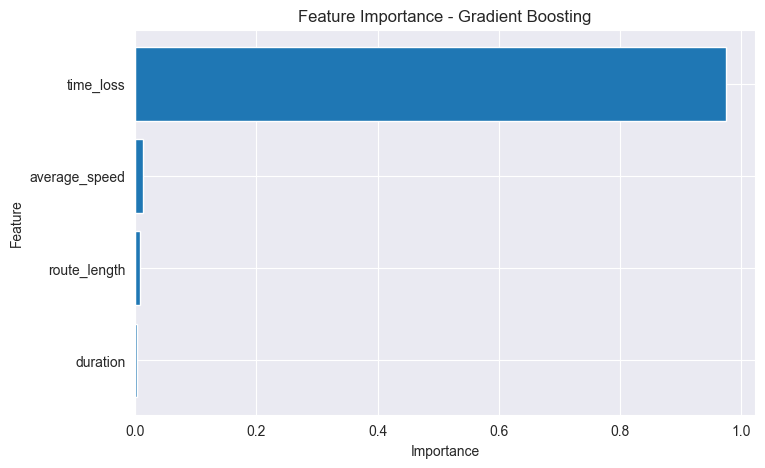

In [103]:
#Feature Importance
importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("Feature Importance:")
print(feature_importance_df)

plt.figure(figsize=(8,5))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Gradient Boosting")
plt.gca().invert_yaxis()  # highest importance on top
plt.show()


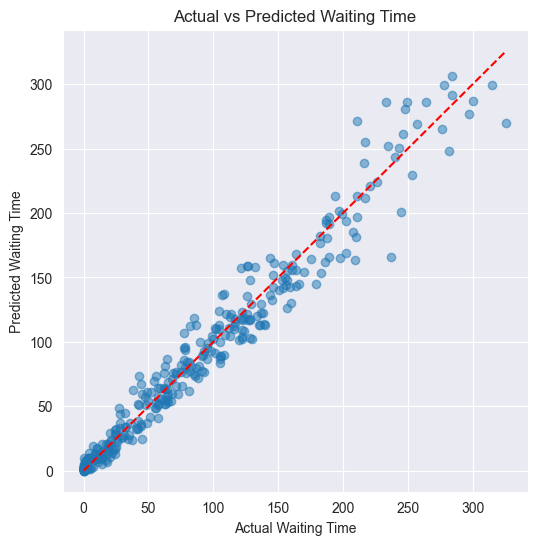

In [104]:
#Actual vs Predicted plot
plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_test_pred, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         'r--')  # diagonal line for perfect prediction
plt.xlabel("Actual Waiting Time")
plt.ylabel("Predicted Waiting Time")
plt.title("Actual vs Predicted Waiting Time")
plt.show()

In [105]:
#Comparison table with vehicle ID
comparison = pd.DataFrame({
    "Vehicle ID": df.iloc[y_test.index]["vehicle_id"],
    "Actual Waiting Time": y_test_actual,
    "Predicted Waiting Time": y_test_pred,
    "Error": abs(y_test_actual - y_test_pred)
})

print(comparison.sort_values("Error", ascending=False).head(20))

      Vehicle ID  Actual Waiting Time  Predicted Waiting Time      Error
254          217                237.0              166.020381  70.979619
619          584                211.0              271.771989  60.771989
1524        1671                326.0              269.900865  56.099135
1379        1589                233.0              285.824696  52.824696
316          268                209.0              163.439709  45.560291
1398        1703                245.0              200.843799  44.156201
680          625                217.0              255.452609  38.452609
1157        1281                249.0              285.945046  36.945046
1644        1990                121.0              157.462031  36.462031
78            97                179.0              145.094920  33.905080
265          152                282.0              248.461519  33.538481
1370        1558                 85.0              118.161549  33.161549
185           78                198.0              

In [106]:
#Save model
#joblib.dump(best_model, "manual_waiting_time_model.pkl")
print("Model saved as manual_waiting_time_model_log.pkl")

Model saved as manual_waiting_time_model_log.pkl
